In [1]:
!pip install kaggle -q

In [2]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"israelsnchezarenas","key":"07d4fb287258607752323636fc6d2f83"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:15<00:00, 41.4MB/s]



In [5]:
!unzip -q gtsrb-german-traffic-sign.zip -d gtsrb

In [6]:
import os

os.listdir("gtsrb")

['Meta',
 'Test.csv',
 'meta',
 'Train.csv',
 'test',
 'train',
 'Train',
 'Meta.csv',
 'Test']

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
!cp -r gtsrb /content/drive/MyDrive/GTSRB

In [10]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

In [11]:
DATASET_PATH = "/content/gtsrb"
TRAIN_PATH = os.path.join(DATASET_PATH, "Train")
TEST_PATH = os.path.join(DATASET_PATH, "Test")

In [12]:
IMG_SIZE = 32

In [13]:
IMG_SIZE = 32
NUM_CLASSES = 43

images = []
labels = []

for class_id in range(NUM_CLASSES):
    class_path = os.path.join(TRAIN_PATH, str(class_id))

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        images.append(img)
        labels.append(class_id)

X = np.array(images)
y = np.array(labels)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (39209, 32, 32, 3)
Shape de y: (39209,)


In [14]:
X = X.astype("float32") / 255.0

In [15]:
y_cat = to_categorical(y, NUM_CLASSES)

In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Validación:", X_val.shape)

Entrenamiento: (31367, 32, 32, 3)
Validación: (7842, 32, 32, 3)


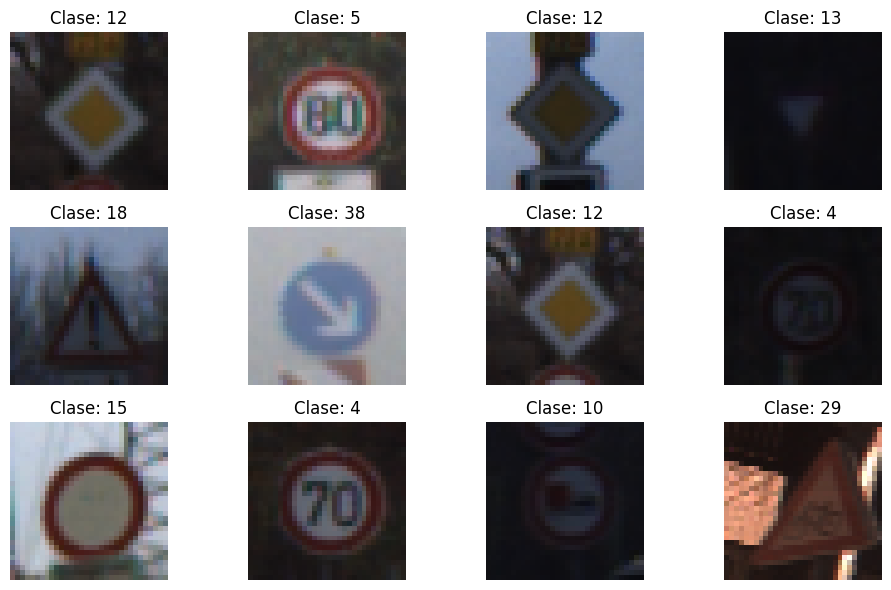

In [17]:
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i])
    plt.axis("off")
    plt.title(f"Clase: {np.argmax(y_train[i])}")

plt.tight_layout()
plt.show()

### Arquitectura CNN recomendada

In [18]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Bloque convolucional 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Bloque convolucional 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Bloque convolucional 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Clasificador
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.50),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

In [19]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,603 (3.14 MB)

 Trainable params: 822,603 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.10)
])

In [21]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.50),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### Entrenamiento de la red neuronal

In [22]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

In [23]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.1406 - loss: 3.1575 - val_accuracy: 0.3984 - val_loss: 1.8856 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.4553 - loss: 1.6978 - val_accuracy: 0.6580 - val_loss: 0.9926 - learning_rate: 0.0010
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6715 - loss: 0.9901 - val_accuracy: 0.8718 - val_loss: 0.3714 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8092 - loss: 0.5808 - val_accuracy: 0.9546 - val_loss: 0.1404 - learning_rate: 0.0010
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8810 - loss: 0.3779 - val_accuracy: 0.9793 - val_loss: 0.0728 - learning_rate: 0.0010
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9055 - loss: 0.2933 - val_accuracy: 0.9887 - val_loss: 0.0431 - learning_rate: 0.0010
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9258 - loss:

### Graficación de accuracy y loss

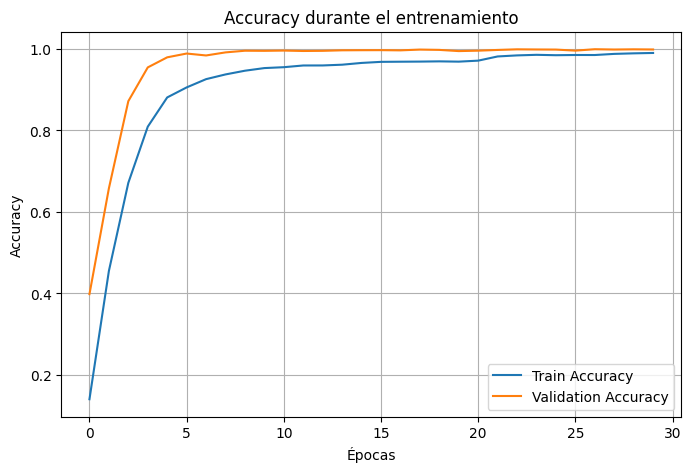

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.legend()
plt.grid()
plt.show()

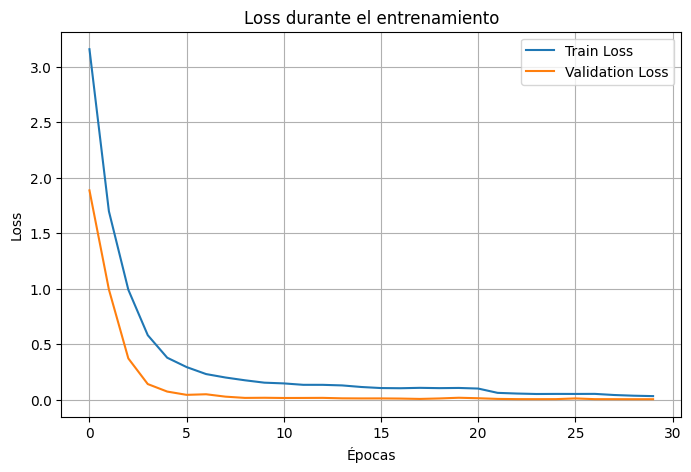

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Loss durante el entrenamiento")
plt.legend()
plt.grid()
plt.show()

### Evaluacion del modelo

In [26]:
val_loss, val_acc = model.evaluate(X_val, y_val)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9992 - loss: 0.0044
Validation Loss: 0.0044
Validation Accuracy: 0.9992


In [27]:
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

print(classification_report(y_true, y_pred))

246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00       444
           2       1.00      1.00      1.00       450
           3       1.00      1.00      1.00       282
           4       1.00      1.00      1.00       396
           5       1.00      1.00      1.00       372
           6       1.00      1.00      1.00        84
           7       1.00      1.00      1.00       288
           8       1.00      1.00      1.00       282
           9       1.00      1.00      1.00       294
          10       1.00      1.00      1.00       402
          11       1.00      1.00      1.00       264
          12       1.00      1.00      1.00       420
          13       1.00      1.00      1.00       432
          14       1.00      1.00      1.00       156
          15       1.00      0.99      1.00       126
          16       1.00      1.00      1

### Carga y evalición con el conjunto de prueba

In [28]:
test_df = pd.read_csv(os.path.join(DATASET_PATH, "Test.csv"))
test_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


In [29]:
test_images = []
test_labels = []

for _, row in test_df.iterrows():
    img_path = os.path.join(DATASET_PATH, row["Path"])

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    test_images.append(img)
    test_labels.append(row["ClassId"])

X_test = np.array(test_images).astype("float32") / 255.0
y_test = np.array(test_labels)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (12630, 32, 32, 3)
y_test: (12630,)


In [30]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9780 - loss: 0.1252
Test Loss: 0.1252
Test Accuracy: 0.9780


### Matriz de confusion

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


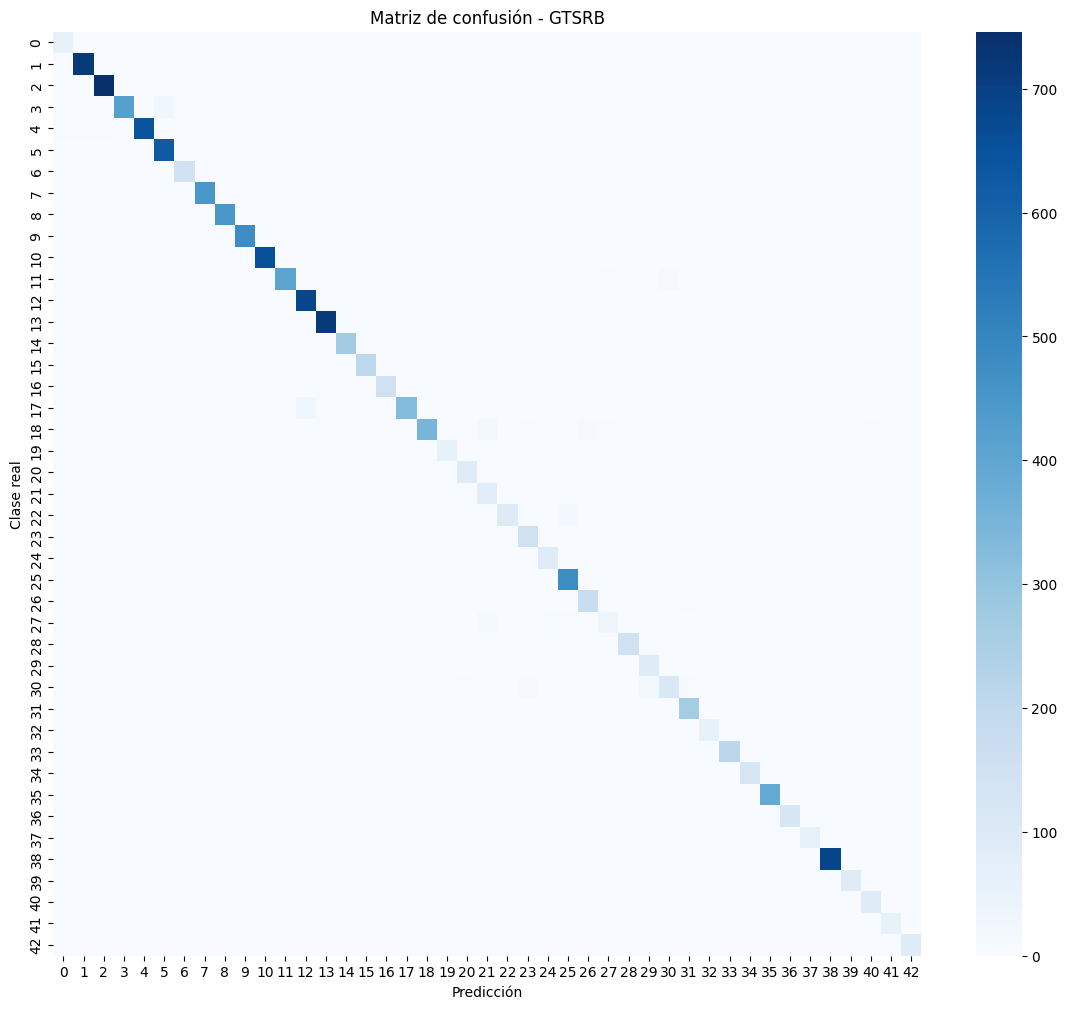

In [31]:
import seaborn as sns

y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", annot=False)
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - GTSRB")
plt.show()

In [32]:
model.save("/content/drive/MyDrive/modelo_gtsrb_cnn.keras")

### 16. Explicación breve de la arquitectura propuesta

La arquitectura propuesta inicia con capas convolucionales pequeñas de 3x3, adecuadas para detectar patrones locales como bordes, esquinas, colores y formas internas de las señales. Después se agregan capas de MaxPooling2D, que reducen progresivamente el tamaño espacial de la imagen y ayudan a conservar las características más relevantes. Este diseño es apropiado para imágenes pequeñas como las de GTSRB, que se redimensionan a 32x32x3.

El modelo incrementa gradualmente el número de filtros: primero 32, luego 64 y finalmente 128. Esto permite que las primeras capas aprendan características simples y las capas más profundas aprendan patrones más complejos. Posteriormente se utiliza Flatten para convertir los mapas de características en un vector, seguido de una capa Dense de 256 neuronas para la clasificación final.

También se agrega Dropout en varias etapas para reducir el sobreajuste. Finalmente, la última capa usa softmax con 43 neuronas, una por cada clase del dataset. Esta salida es adecuada porque el problema consiste en clasificar cada imagen en una sola categoría de señal de tránsito.

### Exportacion del modelo

In [33]:
model.save("modelo_gtsrb_cnn.keras")